# CG-SENSE Parallel Imaging MRI Reconstruction

This notebook demonstrates **Conjugate Gradient SENSE (CG-SENSE)** for multi-coil MRI reconstruction. Unlike GRAPPA (which interpolates missing k-space samples), CG-SENSE works in the **image domain** by directly solving the SENSE encoding equation using conjugate gradient.

Loads precomputed reference outputs — runs in seconds.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from src.preprocessing import load_observation, load_ground_truth, get_full_kspace, get_sensitivity_maps, undersample_kspace
from src.visualization import compute_metrics, print_metrics

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [2]:
DATA_DIR = os.path.join('..', 'data')
REF_DIR = os.path.join('..', 'evaluation', 'reference_outputs')

obs = load_observation(DATA_DIR)
kf = get_full_kspace(obs)
sens = get_sensitivity_maps(obs)
gt_raw = load_ground_truth(DATA_DIR)[0]

recon = np.load(os.path.join(REF_DIR, 'sense_reconstruction.npz'))['reconstruction'][0]
zf = np.load(os.path.join(REF_DIR, 'zerofill.npz'))['reconstruction'][0]
gt = np.load(os.path.join(REF_DIR, 'fully_sampled.npy'))

kus, mask = undersample_kspace(kf, R=4, acs_width=16)

print(f'K-space: {kf.shape} ({kf.shape[-1]} coils)')
print(f'Sensitivity maps: {sens.shape}')
print(f'Sampling: {mask.sum()}/{len(mask)} = {mask.sum()/len(mask)*100:.1f}% PE lines (R=4)')

K-space: (128, 128, 8) (8 coils)
Sensitivity maps: (128, 128, 8)
Sampling: 44/128 = 34.4% PE lines (R=4)


## 2. Coil Sensitivity Maps

Gaussian sensitivity maps simulate the spatial sensitivity profiles of 8 receiver coils arranged in a circle.

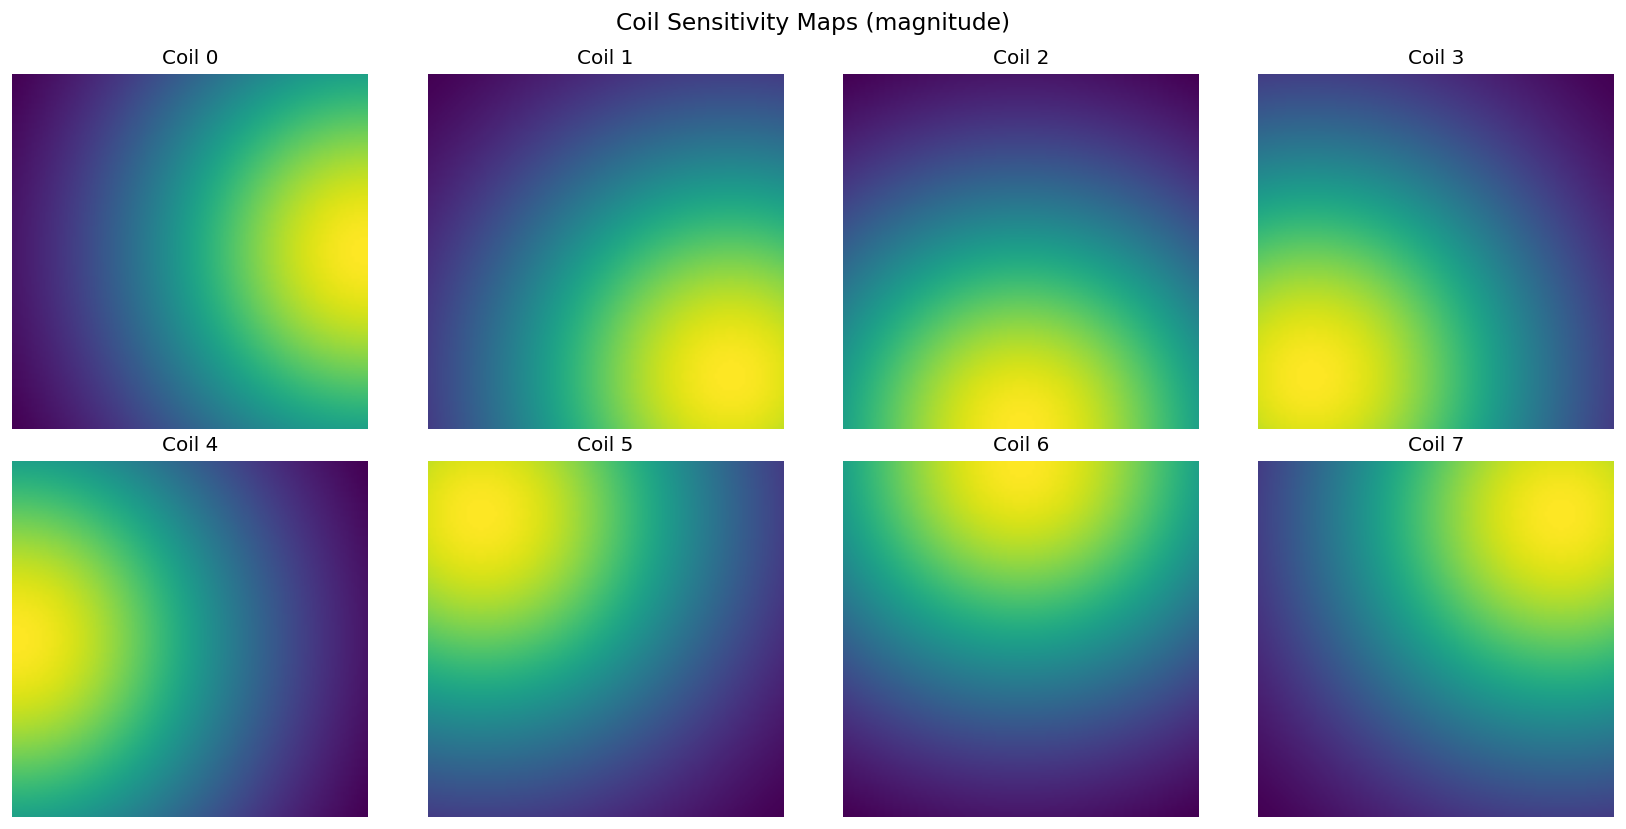

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(8):
    r, c = divmod(i, 4)
    axes[r, c].imshow(np.abs(sens[..., i]), cmap='viridis')
    axes[r, c].set_title(f'Coil {i}')
    axes[r, c].axis('off')
plt.suptitle('Coil Sensitivity Maps (magnitude)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Undersampling Pattern

R=4 acceleration: every 4th phase-encode line is acquired, plus a 16-line ACS region at k-space centre.

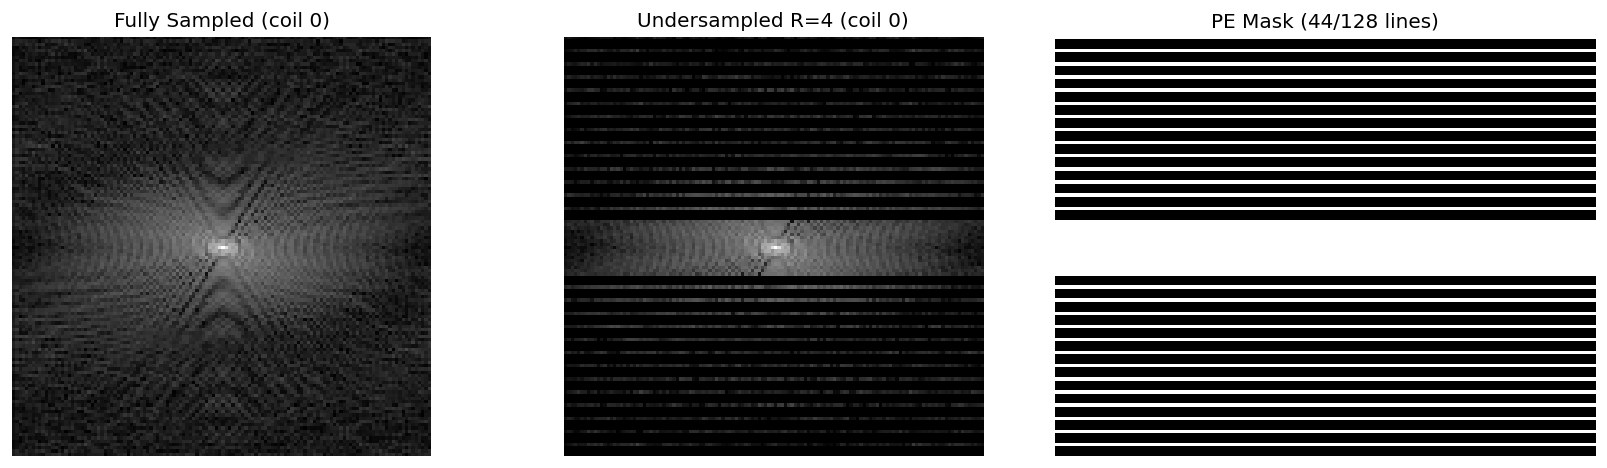

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(np.log1p(np.abs(kf[..., 0])), cmap='gray')
axes[0].set_title('Fully Sampled (coil 0)')
axes[1].imshow(np.log1p(np.abs(kus[..., 0])), cmap='gray')
axes[1].set_title('Undersampled R=4 (coil 0)')
axes[2].imshow(mask[:, None] * np.ones((1, 128)), cmap='gray', aspect='auto')
axes[2].set_title(f'PE Mask ({mask.sum()}/128 lines)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Reconstruction Comparison

Zero-fill (aliased RSS) vs CG-SENSE vs ground truth.

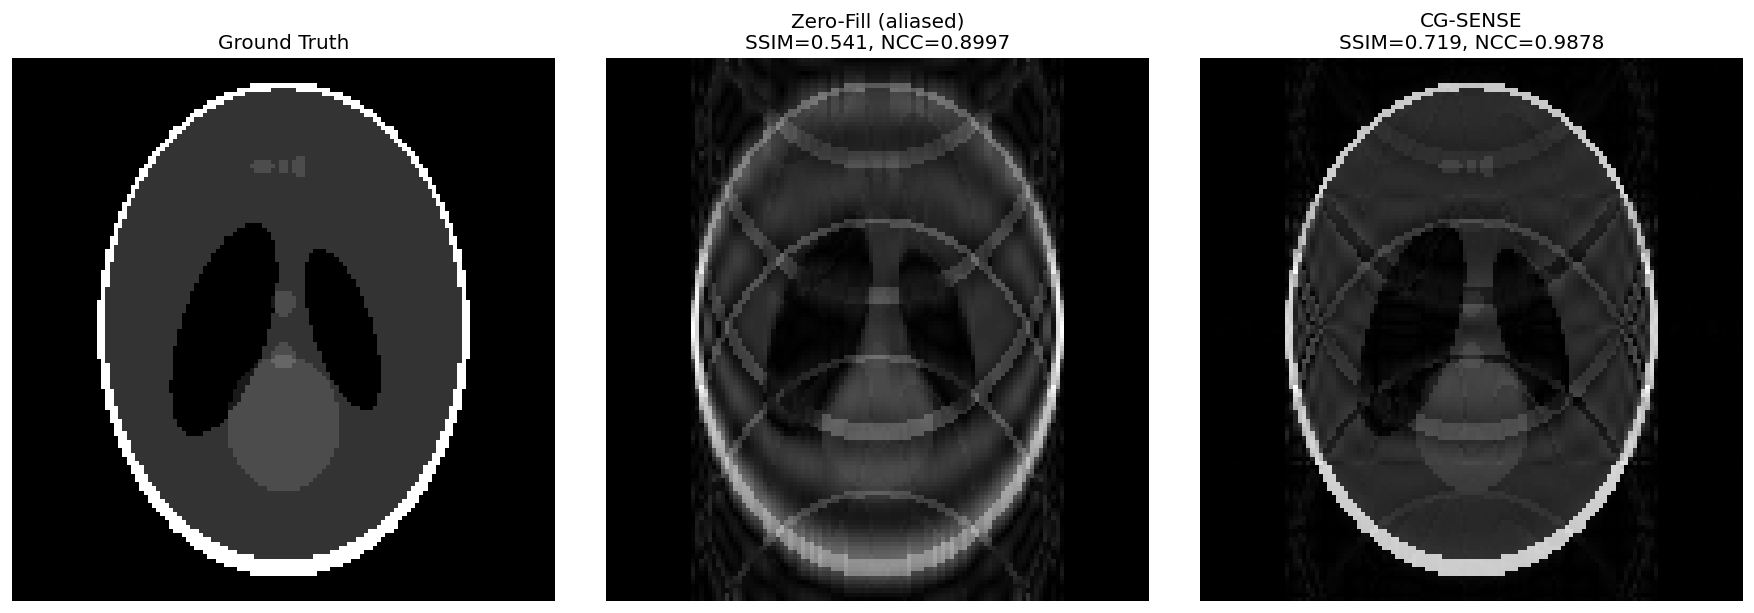

In [5]:
m_s = compute_metrics(recon, gt)
m_zf = compute_metrics(zf, gt)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes,
    [gt, zf, recon],
    ['Ground Truth',
     f'Zero-Fill (aliased)\nSSIM={m_zf["ssim"]:.3f}, NCC={m_zf["ncc"]:.4f}',
     f'CG-SENSE\nSSIM={m_s["ssim"]:.3f}, NCC={m_s["ncc"]:.4f}']):
    ax.imshow(np.abs(img), cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Error Maps

/var/folders/g6/91c6hhdn27b9rch26vg33z240000gp/T/ipykernel_57310/604959280.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


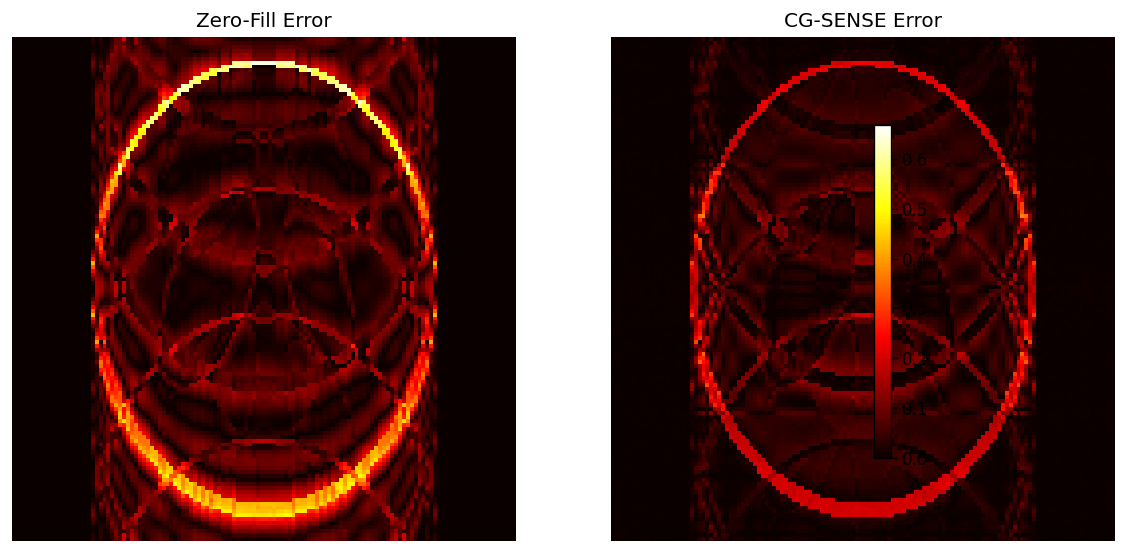

In [6]:
err_zf = np.abs(zf - gt)
err_s = np.abs(recon - gt)
vmax = max(err_zf.max(), err_s.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(err_zf, cmap='hot', vmin=0, vmax=vmax)
axes[0].set_title('Zero-Fill Error'); axes[0].axis('off')
im = axes[1].imshow(err_s, cmap='hot', vmin=0, vmax=vmax)
axes[1].set_title('CG-SENSE Error'); axes[1].axis('off')
plt.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

## 6. Quantitative Metrics

In [7]:
print('=' * 50)
print('CG-SENSE vs Ground Truth:')
print_metrics(m_s)
print('\nZero-Fill vs Ground Truth:')
print_metrics(m_zf)
print('=' * 50)
print(f'\nSSIM improvement: {m_s["ssim"] - m_zf["ssim"]:.3f}')
print(f'NRMSE reduction: {(1 - m_s["nrmse"]/m_zf["nrmse"])*100:.1f}%')

CG-SENSE vs Ground Truth:
  SSIM:  0.7191
  NCC:   0.987777
  NRMSE: 0.057180

Zero-Fill vs Ground Truth:
  SSIM:  0.5405
  NCC:   0.899726
  NRMSE: 0.110315

SSIM improvement: 0.179
NRMSE reduction: 48.2%


## 7. Run from Scratch (Optional)

In [8]:
# from src.solvers import cgsense_image_recon
# recon_new = cgsense_image_recon(kus, sens)
# m = compute_metrics(recon_new, gt)
# print(f'SSIM={m["ssim"]:.4f}, NCC={m["ncc"]:.6f}, NRMSE={m["nrmse"]:.6f}')

## Conclusion

CG-SENSE reconstructs from 4x-accelerated multi-coil k-space by solving the SENSE encoding equation in the image domain via conjugate gradient:

- **SSIM: 0.719** (vs 0.541 for zero-fill) — 33% improvement
- **NRMSE: 0.057** (vs 0.110 for zero-fill) — 48% reduction
- Works by forming the normal equations $A^H A x = A^H y$ and solving with scipy's CG
- Complementary to GRAPPA: SENSE works in image domain, GRAPPA works in k-space domain